In [3]:
import pandas as pd
import numpy as np

In [4]:
def load_netflix_file(filepath):
    
    data = []
    movie_id = None

    with open(filepath, "r") as f:
        for line in f:

            line = line.strip()

            if line.endswith(":"):
                movie_id = int(line[:-1])

            else:
                user_id, rating, date = line.split(",")

                data.append([
                    int(user_id),
                    movie_id,
                    int(rating),
                    date
                ])

    return pd.DataFrame(
        data,
        columns=[
            "user_id",
            "movie_id",
            "rating",
            "date"
        ]
    )

In [6]:
ratings = load_netflix_file("../combined_data_1.txt")

In [7]:
ratings.shape

(24053764, 4)

In [8]:
ratings.head()

,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [9]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24053764 entries, 0 to 24053763
Data columns (total 4 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   user_id   int64 
 1   movie_id  int64 
 2   rating    int64 
 3   date      object
dtypes: int64(3), object(1)
memory usage: 734.1+ MB


In [10]:
ratings.isnull().sum()

user_id     0
movie_id    0
rating      0
date        0
dtype: int64

In [12]:
import pandas as pd

movies = pd.read_csv(
    "../movie_titles.csv",
    header=None,
    encoding="latin-1",
    on_bad_lines="skip"
)

In [13]:
movies.head()

,0,1,2
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [14]:
movies.columns = ["movie_id", "year", "title"]

In [15]:
movies.head()

,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [16]:
print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)

Ratings Shape: (24053764, 4)
Movies Shape: (17434, 3)


In [18]:
print("Number of Users :", ratings["user_id"].nunique())
print("Number of Movies :", ratings["movie_id"].nunique())
print("Total Ratings :", len(ratings))

Number of Users : 470758
Number of Movies : 4499
Total Ratings : 24053764


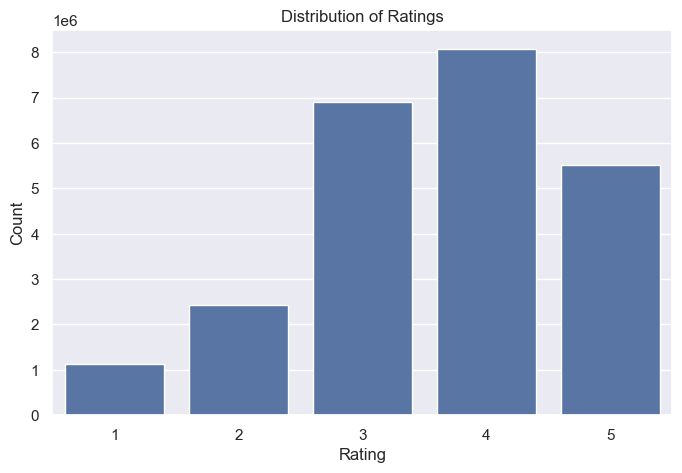

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=ratings, x="rating")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [20]:
ratings_per_user = ratings.groupby("user_id").size()

ratings_per_user.describe()

count    470758.000000
mean         51.095816
std          74.405055
min           1.000000
25%           8.000000
50%          24.000000
75%          64.000000
max        4467.000000
dtype: float64

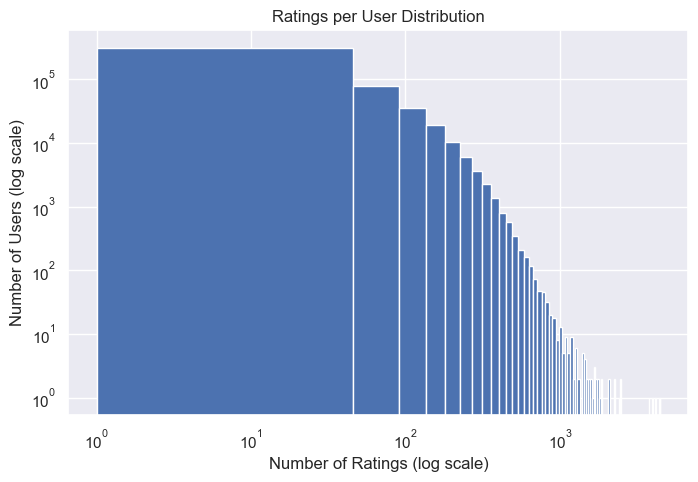

In [24]:
plt.figure(figsize=(8,5))

plt.hist(ratings_per_user, bins=100)

plt.xscale("log")
plt.yscale("log")

plt.title("Ratings per User Distribution")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Number of Users (log scale)")

plt.show()

In [22]:
ratings_per_user.sort_values(ascending=False).head(10)

user_id
305344     4467
387418     4422
2439493    4195
1664010    4019
2118461    3769
1639792    2500
1314869    2467
1461435    2449
1932594    2263
2606799    2241
dtype: int64

Most users rate only a limited number of movies, while a small number of highly active users contribute a disproportionately large number of ratings. This long-tail behavior is common in recommendation systems and creates challenges for learning preferences for less active users.

In [23]:
ratings_per_user.describe()

count    470758.000000
mean         51.095816
std          74.405055
min           1.000000
25%           8.000000
50%          24.000000
75%          64.000000
max        4467.000000
dtype: float64

content popularities trend 

In [25]:
ratings_per_movie = ratings.groupby("movie_id").size()

ratings_per_movie.describe()

count      4499.000000
mean       5346.468993
std       16176.313851
min          36.000000
25%         192.000000
50%         552.000000
75%        2538.000000
max      193941.000000
dtype: float64

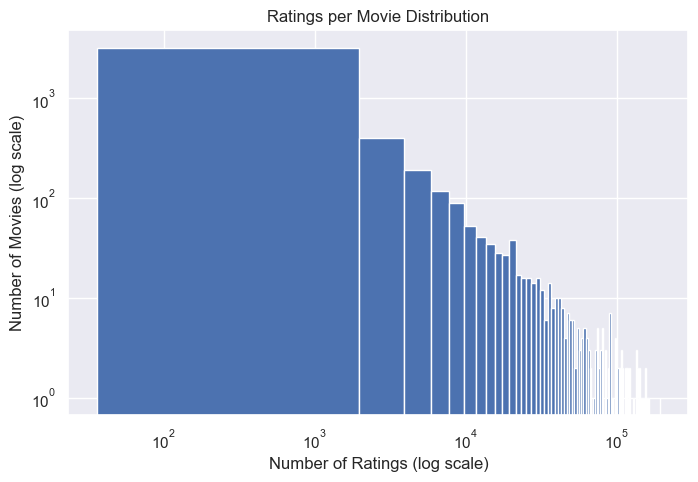

In [26]:
plt.figure(figsize=(8,5))

plt.hist(ratings_per_movie, bins=100)

plt.xscale("log")
plt.yscale("log")

plt.title("Ratings per Movie Distribution")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Number of Movies (log scale)")

plt.show()

In [27]:
movie_counts = (
    ratings.groupby("movie_id")
    .size()
    .reset_index(name="num_ratings")
)

top_movies = (
    movie_counts
    .merge(movies, on="movie_id")
    .sort_values("num_ratings", ascending=False)
    .head(10)
)

top_movies

,movie_id,num_ratings,year,title
1870,1905,193941,2003.0,Pirates of the Caribbean: The Curse of the Bla...
2116,2152,162597,2000.0,What Women Want
3789,3860,160454,2003.0,Bruce Almighty
4349,4432,156183,2003.0,The Italian Job
564,571,154832,1999.0,American Beauty
3865,3938,153996,2004.0,Shrek 2
4225,4306,151292,1999.0,The Sixth Sense
2410,2452,149866,2001.0,Lord of the Rings: The Fellowship of the Ring
1927,1962,145519,2004.0,50 First Dates
3889,3962,140979,2003.0,Finding Nemo (Widescreen)


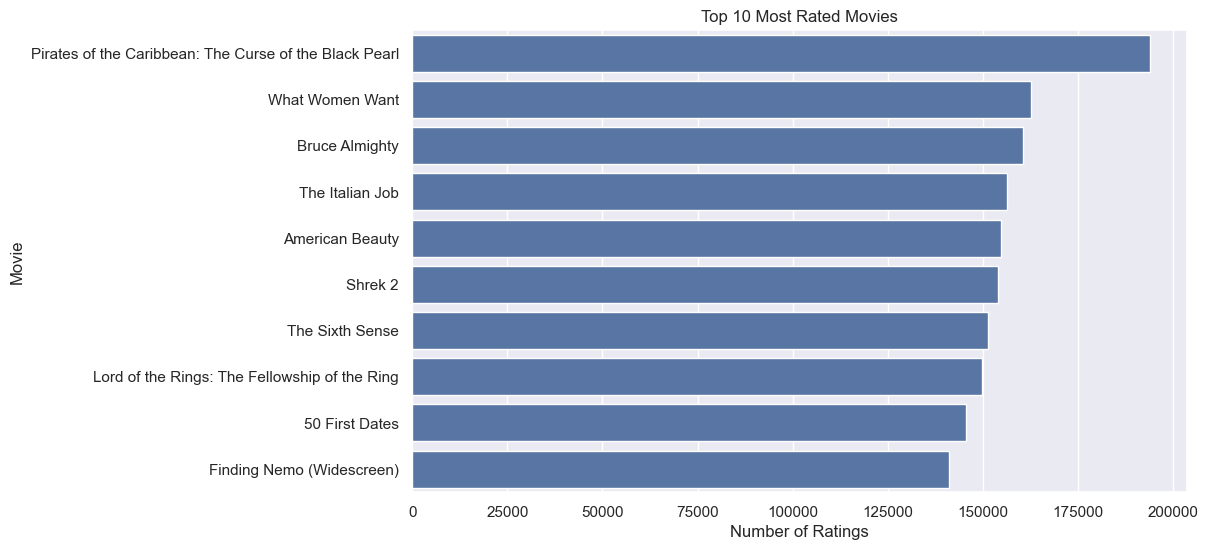

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_movies,
    x="num_ratings",
    y="title"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.show()

In [29]:
ratings_per_movie.describe()

count      4499.000000
mean       5346.468993
std       16176.313851
min          36.000000
25%         192.000000
50%         552.000000
75%        2538.000000
max      193941.000000
dtype: float64

sparsity analysis 

In [30]:
num_users = ratings["user_id"].nunique()
num_movies = ratings["movie_id"].nunique()

possible_ratings = num_users * num_movies
actual_ratings = len(ratings)

sparsity = 1 - (actual_ratings / possible_ratings)

print(f"Users: {num_users:,}")
print(f"Movies: {num_movies:,}")
print(f"Actual Ratings: {actual_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

Users: 470,758
Movies: 4,499
Actual Ratings: 24,053,764
Sparsity: 98.8643%


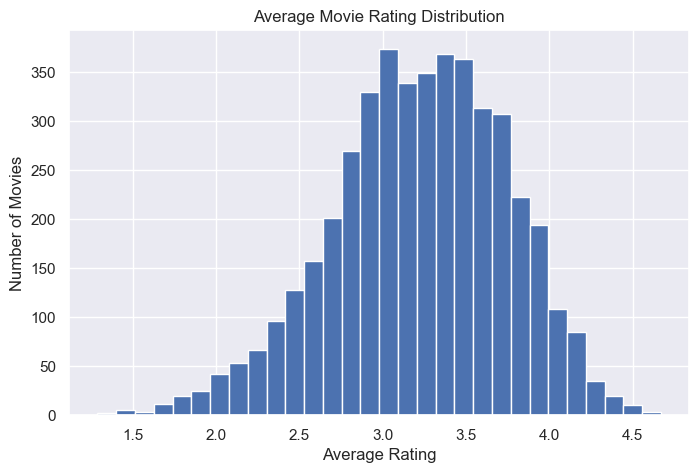

In [31]:
movie_avg_rating = (
    ratings.groupby("movie_id")["rating"]
    .mean()
)

plt.figure(figsize=(8,5))
plt.hist(movie_avg_rating, bins=30)

plt.title("Average Movie Rating Distribution")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")

plt.show()

In [32]:
num_users = ratings["user_id"].nunique()
num_movies = ratings["movie_id"].nunique()

possible_ratings = num_users * num_movies
actual_ratings = len(ratings)

sparsity = 1 - (actual_ratings / possible_ratings)

print(f"Users: {num_users:,}")
print(f"Movies: {num_movies:,}")
print(f"Actual Ratings: {actual_ratings:,}")
print(f"Possible Ratings: {possible_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

Users: 470,758
Movies: 4,499
Actual Ratings: 24,053,764
Possible Ratings: 2,117,940,242
Sparsity: 98.8643%


In [33]:
movie_stats = ratings.groupby("movie_id").agg(
    num_ratings=("rating", "count"),
    avg_rating=("rating", "mean")
)

top_rated = (
    movie_stats[movie_stats["num_ratings"] >= 1000]
    .reset_index()
    .merge(movies, on="movie_id")
    .sort_values("avg_rating", ascending=False)
    .head(10)
)

top_rated[["title", "avg_rating", "num_ratings"]]

,title,avg_rating,num_ratings
1306,Lost: Season 1,4.670989,7249
792,The Simpsons: Season 6,4.581296,8426
1596,Inu-Yasha,4.554434,1883
1300,Family Guy: Freakin' Sweet Collection,4.516007,10027
1681,The West Wing: Season 3,4.473692,6633
566,Six Feet Under: Season 4,4.469693,11829
768,Samurai Champloo,4.467500,2000
981,Stargate SG-1: Season 8,4.461921,1812
741,Gilmore Girls: Season 3,4.448333,4829
800,Firefly,4.446714,10772


### Key Findings

* Most ratings are between 3 and 5 stars, which shows that users generally give positive ratings to movies they watch.
* User activity is not evenly distributed. Most users rate only a few movies, while a small number of users rate hundreds or even thousands of movies.
* Movie popularity also follows a similar pattern. A few popular movies receive a very large number of ratings, whereas many movies receive relatively few ratings.
* The average rating of most movies lies between 3 and 4 stars, indicating that users tend to rate movies moderately well.
* The dataset is highly sparse, with a sparsity of about 98.8%. This means users have rated only a small fraction of the available movies.
* These patterns make the dataset a good fit for recommendation systems that can learn user preferences and predict ratings for unseen movies.

